In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from mlxtend.plotting import plot_decision_regions

In [6]:
X,y=make_circles(n_samples=100, noise=0.2, random_state=42)

<Axes: >

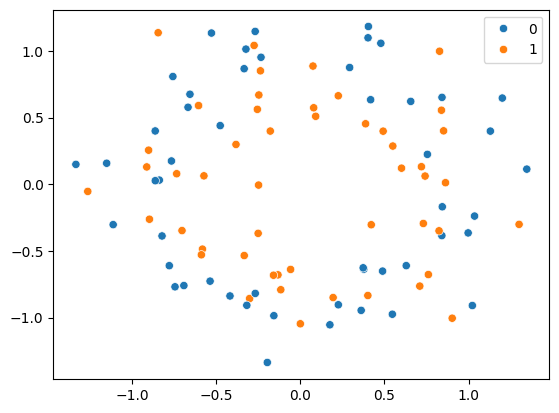

In [7]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)

In [8]:
X_train,X_test, y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [9]:
model=Sequential()
model.add(Dense(8, input_dim=2, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [12]:
history=model.fit(X_train,y_train, validation_data=(X_test,y_test), epochs=1000, verbose=0)

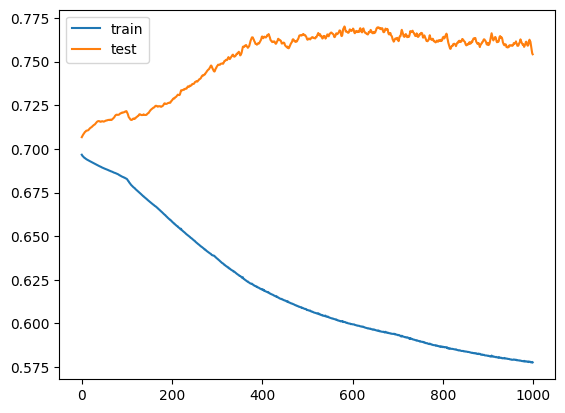

In [13]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')

plt.legend(['train', 'test'], loc='upper left')

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


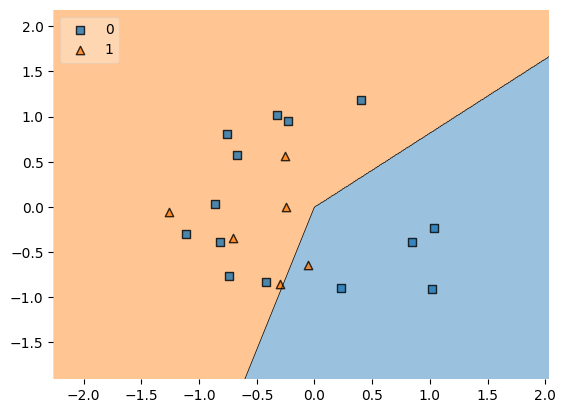

In [17]:
plot_decision_regions(X_test, y_test.ravel(), clf=model,legend=2)
plt.show()

# **Early Stopping**

In [16]:
model=Sequential()
model.add(Dense(8, input_dim=2, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
callback=EarlyStopping(monitor='val_loss',min_delta=0.000001, verbose=1, mode='auto', patience=20)

In [24]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [25]:
history=model.fit(X_train,y_train, validation_data=(X_test,y_test), epochs=1000, verbose=1,callbacks=[callback])

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step - accuracy: 0.5250 - loss: 0.6988 - val_accuracy: 0.4500 - val_loss: 0.7307
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5125 - loss: 0.6986 - val_accuracy: 0.4500 - val_loss: 0.7310
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5125 - loss: 0.6983 - val_accuracy: 0.4500 - val_loss: 0.7308
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5250 - loss: 0.6980 - val_accuracy: 0.4500 - val_loss: 0.7305
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5250 - loss: 0.6978 - val_accuracy: 0.4500 - val_loss: 0.7305
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5250 - loss: 0.6977 - val_accuracy: 0.4500 - val_loss: 0.7302
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5375 - loss: 0.6974 - val_accuracy: 0.4000 - val_loss: 0.7297
Epoch 8/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5375 - loss: 0.6972 - val_accuracy: 0.4000 - 

In [ ]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')

plt.legend(['train', 'test'], loc='upper left')

In [ ]:
plot_decision_regions(X_test, y_test.ravel(), clf=model,legend=2)
plt.show()